# Used Car Price Prediction – Regression Project

Author: Matej Brnjić

Date: 31.08.2026

## Project objective

This project develops a machine learning regression system that predicts the **`priceUSD`** of a used car from its characteristics.

The workflow follows the complete machine learning process:

**EDA → Data Cleaning → Feature Engineering → Preprocessing → Model Training → Evaluation → Model Selection**

The dataset contains **56,244 rows and 12 columns** before cleaning. The final model is selected using regression metrics, with special attention to **MAE (Mean Absolute Error)** because it is directly interpretable in US dollars.


## 1. Import libraries and project modules

The reusable logic is stored in the `source/` directory. Keeping data preparation and model code in separate Python modules makes the project easier to test, maintain, and reuse.


In [62]:
import os
import sys
from pathlib import Path

# Enables automatic reloading of modified .py files
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from source.data_cleaning import clean_data
from source.feature_engineering import add_features
from source.data_preprocessing import split_features_target


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load the raw dataset

The target variable is `priceUSD`. All other columns describe the vehicle and may be used as predictive features.


In [63]:
data_path = Path("data/cars.csv")
df_raw = pd.read_csv(data_path)

print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())


Dataset shape: (56244, 12)


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## 3. Initial data inspection

We inspect data types, missing values, duplicated rows, and basic statistics before making any changes.


In [64]:
print("Data types:")
display(df_raw.dtypes)

print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False))

print(f"\nDuplicate rows: {df_raw.duplicated().sum():,}")

display(df_raw.describe(include="all").T)


Data types:


make                       str
model                      str
priceUSD                 int64
year                     int64
condition                  str
mileage(kilometers)    float64
fuel_type                  str
volume(cm3)            float64
color                      str
transmission               str
drive_unit                 str
segment                    str
dtype: object


Missing values:


segment                5291
drive_unit             1905
volume(cm3)              47
make                      0
year                      0
priceUSD                  0
model                     0
condition                 0
fuel_type                 0
mileage(kilometers)       0
transmission              0
color                     0
dtype: int64


Duplicate rows: 87


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
make,56244,96,volkswagen,6861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,56244,1034,passat,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priceUSD,56244.0,NaN,NaN,NaN,7415.45644,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0
year,56244.0,NaN,NaN,NaN,2003.45484,8.144247,1910.0,1998.0,2004.0,2010.0,2019.0
condition,56244,3,with mileage,55278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage(kilometers),56244.0,NaN,NaN,NaN,244395.63102,321030.668382,0.0,137000.0,228500.0,310000.0,9999999.0
fuel_type,56244,3,petrol,36405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
volume(cm3),56197.0,NaN,NaN,NaN,2104.860615,959.201633,500.0,1600.0,1996.0,2300.0,20000.0
color,56244,13,black,12385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,56244,2,mechanics,36056,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Target variable analysis

The target is highly variable: used-car prices contain both inexpensive vehicles and a small number of very expensive observations.

This is important because extreme prices can strongly affect metrics such as MSE and RMSE.


count     56244.000000
mean       7415.456440
std        8316.959261
min          48.000000
25%        2350.000000
50%        5350.000000
75%        9807.500000
max      235235.000000
Name: priceUSD, dtype: float64


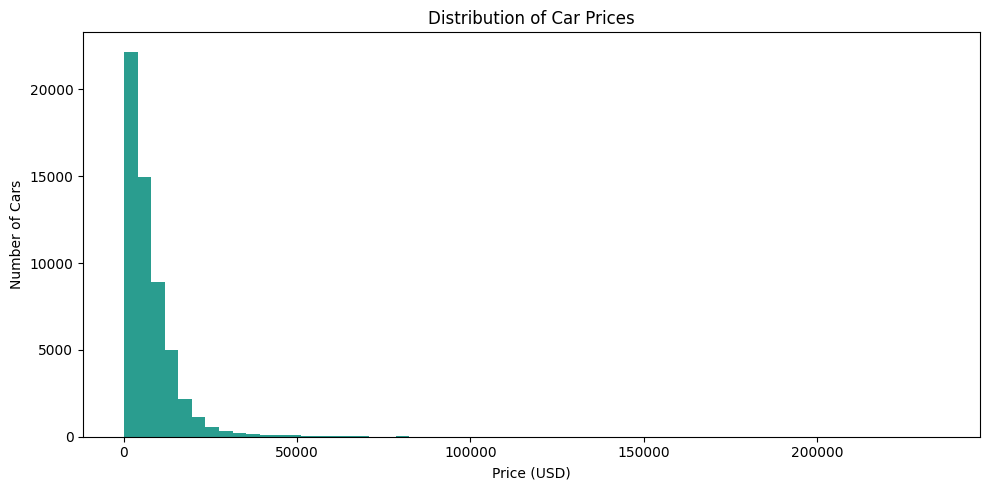

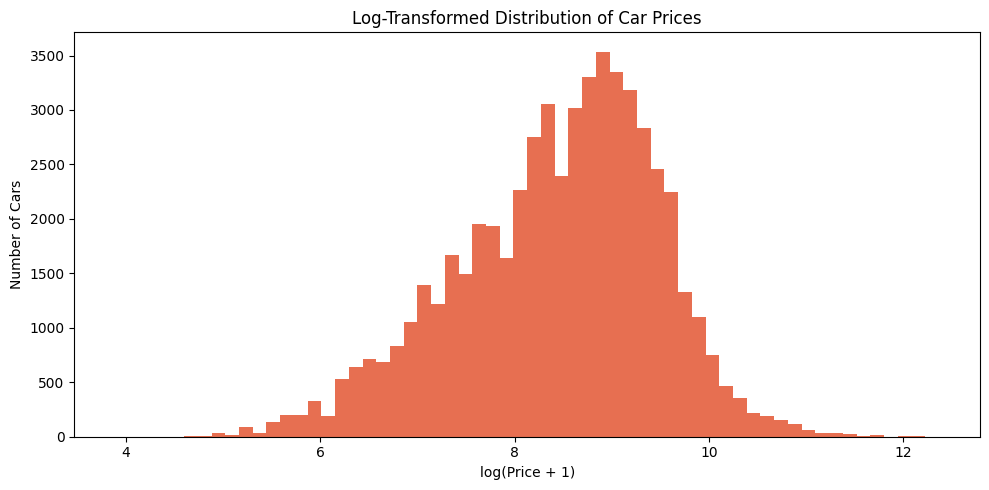

In [65]:
print(df_raw["priceUSD"].describe())

plt.figure(figsize=(10, 5))
plt.hist(df_raw["priceUSD"], bins=60, color="#2a9d8f")
plt.title("Distribution of Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df_raw["priceUSD"]), bins=60, color="#e76f51")
plt.title("Log-Transformed Distribution of Car Prices")
plt.xlabel("log(Price + 1)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()


## 5. Numerical feature exploration

Year, mileage, and engine volume are expected to have a meaningful relationship with vehicle price.

The dataset also contains clear extreme values. For example, the maximum mileage is almost 10 million km and the maximum engine volume is 20,000 cm³, which are unusual for ordinary passenger cars.


,count,mean,std,min,25%,50%,75%,max
priceUSD,56244.0,7415.456440,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0
year,56244.0,2003.454840,8.144247,1910.0,1998.0,2004.0,2010.0,2019.0
mileage(kilometers),56244.0,244395.631020,321030.668382,0.0,137000.0,228500.0,310000.0,9999999.0
volume(cm3),56197.0,2104.860615,959.201633,500.0,1600.0,1996.0,2300.0,20000.0


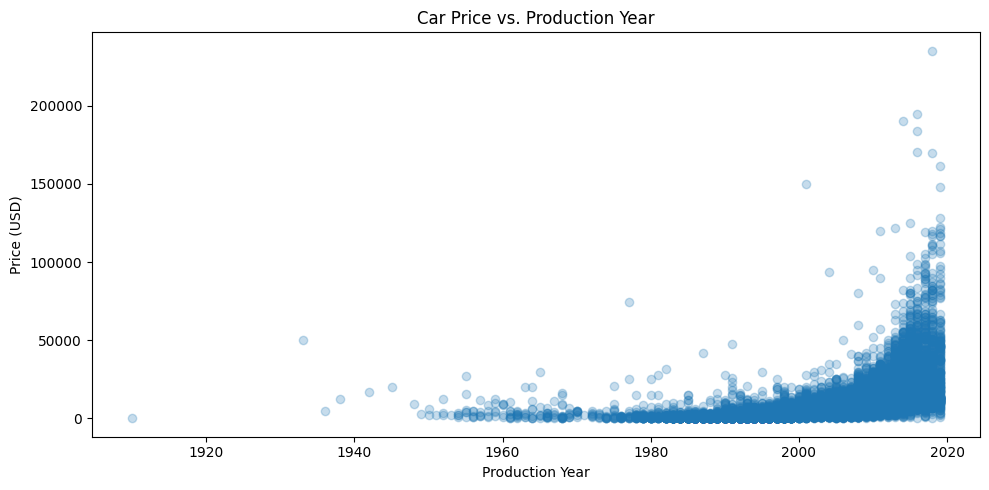

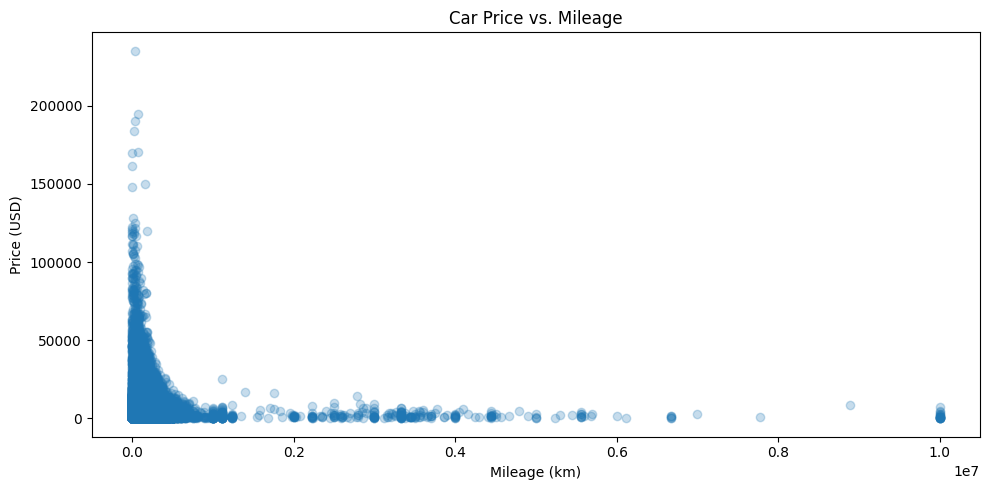

In [66]:
numeric_columns = ["priceUSD", "year", "mileage(kilometers)", "volume(cm3)"]
display(df_raw[numeric_columns].describe().T)

plt.figure(figsize=(10, 5))
plt.scatter(df_raw["year"], df_raw["priceUSD"], alpha=0.25)
plt.title("Car Price vs. Production Year")
plt.xlabel("Production Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(df_raw["mileage(kilometers)"], df_raw["priceUSD"], alpha=0.25)
plt.title("Car Price vs. Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


## 6. Categorical feature exploration

Categorical variables such as make, fuel type, transmission, drive unit, and segment can capture market differences that numerical variables alone cannot explain.



condition:


condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64


fuel_type:


fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64


transmission:


transmission
mechanics    36056
auto         20188
Name: count, dtype: int64


drive_unit:


drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive                5890
part-time four-wheel drive     3597
NaN                            1905
Name: count, dtype: int64


segment:


segment
D      12605
C      10617
J       8629
M       6313
E       6274
NaN     5291
B       4393
F        896
S        765
A        461
Name: count, dtype: int64

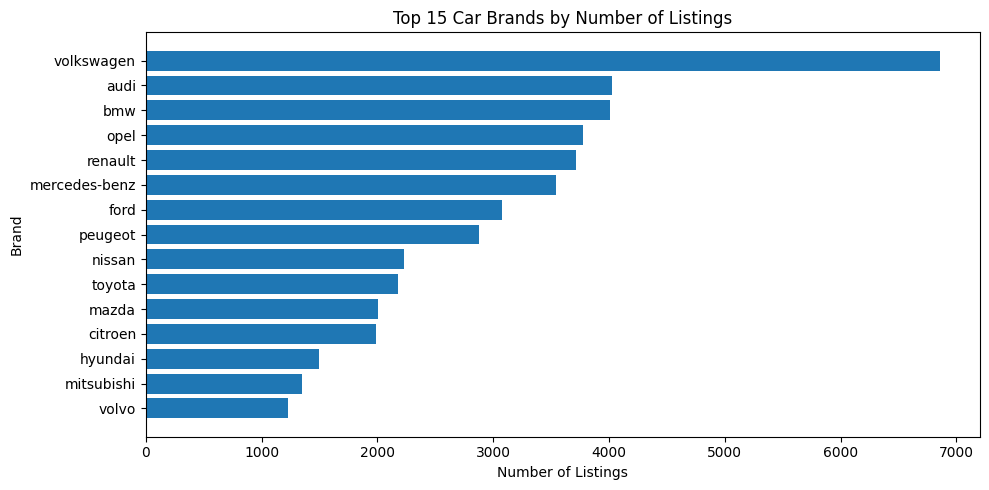

In [67]:
categorical_columns = [
    "condition", "fuel_type", "transmission", "drive_unit", "segment"
]

for column in categorical_columns:
    print(f"\n{column}:")
    display(df_raw[column].value_counts(dropna=False).head(15))

plt.figure(figsize=(10, 5))
top_makes = df_raw["make"].value_counts().head(15)
plt.barh(top_makes.index[::-1], top_makes.values[::-1])
plt.title("Top 15 Car Brands by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


## 7. Data quality findings

The raw dataset contains missing values mainly in:

- `volume(cm3)`
- `drive_unit`
- `segment`

It also contains implausible observations such as very old production years, extremely high mileage, unusually high prices, and unusually large engine volumes.

The cleaning rules are deliberately broad. They remove clearly implausible rows without aggressively deleting legitimate used-car observations.


In [68]:
print("Raw rows:", len(df_raw))

df_clean = clean_data(df_raw)

print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df_raw) - len(df_clean))

print("\nMissing values after cleaning:")
display(df_clean.isna().sum())

print("\nCleaned numeric summary:")
display(df_clean[numeric_columns].describe().T)


Raw rows: 56244
Rows after cleaning: 55535
Rows removed: 709

Missing values after cleaning:


make                      0
model                     0
priceUSD                  0
year                      0
condition                 0
mileage(kilometers)       0
fuel_type                 0
volume(cm3)              47
color                     0
transmission              0
drive_unit             1854
segment                5172
dtype: int64


Cleaned numeric summary:


,count,mean,std,min,25%,50%,75%,max
priceUSD,55535.0,7468.498857,8280.074885,100.0,2400.0,5450.0,9900.0,195000.0
year,55535.0,2003.681084,7.754945,1980.0,1998.0,2004.0,2010.0,2019.0
mileage(kilometers),55535.0,226139.298595,126364.995706,0.0,137000.0,227001.0,307000.0,1000000.0
volume(cm3),55488.0,2081.610456,720.866282,500.0,1600.0,1995.0,2300.0,8000.0


## 8. Feature engineering

Several new features are created:

- **`car_age`** – vehicle age relative to 2026.
- **`mileage_per_year`** – approximate mileage accumulated per year.
- **`engine_volume_liters`** – engine volume in liters, which is easier to interpret.
- **`is_newer_car`** – indicator for newer vehicles.
- **`is_high_mileage`** – indicator for high mileage.
- **`brand_model`** – combined make and model category.

These features add information that is not represented as directly in the original columns.


In [69]:
df_features = add_features(df_clean)

new_features = [
    "car_age", "mileage_per_year", "engine_volume_liters",
    "is_newer_car", "is_high_mileage", "brand_model"
]

display(df_features[new_features].head())
display(df_features[new_features].describe(include="all").T)


,car_age,mileage_per_year,engine_volume_liters,is_newer_car,is_high_mileage,brand_model
0,18,9000.000000,1.5,0,0,mazda_2
1,17,7058.823529,1.3,0,0,mazda_2
2,17,3588.235294,1.5,0,0,mazda_2
3,23,11521.739130,1.4,0,0,mazda_2
4,18,5399.055556,1.4,0,0,mazda_2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_age,55535.0,NaN,NaN,NaN,22.318916,7.754945,7.0,16.0,22.0,28.0,46.0
mileage_per_year,55535.0,NaN,NaN,NaN,10254.703361,4727.452622,0.0,7750.0,10500.0,13166.666667,50000.0
engine_volume_liters,55488.0,NaN,NaN,NaN,2.08161,0.720866,0.5,1.6,1.995,2.3,8.0
is_newer_car,55535.0,NaN,NaN,NaN,0.086774,0.281506,0.0,0.0,0.0,0.0,1.0
is_high_mileage,55535.0,NaN,NaN,NaN,0.300567,0.458509,0.0,0.0,0.0,1.0,1.0
brand_model,55535,1055,volkswagen_passat,2070,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Preprocessing strategy

The preprocessing pipeline is designed to prevent data leakage and make the model usable with raw categorical and numerical data.

For the main one-hot encoded models:

- numerical values → median imputation → standard scaling;
- categorical values → most-frequent imputation → one-hot encoding;
- unknown categories are ignored at prediction time.

For tree/boosting models that work efficiently with compact numeric matrices, an ordinal encoding pipeline is used.

The train/test split is always created with `random_state=42`, so model comparisons are reproducible.


In [70]:
X, y = split_features_target(df_features)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nTarget variable:", y.name)
print("\nNumeric features:")
print(X.select_dtypes(include=np.number).columns.tolist())


Feature matrix shape: (55535, 17)
Target shape: (55535,)

Target variable: priceUSD

Numeric features:
['year', 'mileage(kilometers)', 'volume(cm3)', 'car_age', 'mileage_per_year', 'engine_volume_liters', 'is_newer_car', 'is_high_mileage']


## 10. Model comparison

Four regression algorithms are compared:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting (HistGradientBoostingRegressor)

All models use the same train/test split. The comparison report is produced by `source/model_comparison.py`.


In [71]:
from source.model_comparison import compare_models

comparison = compare_models()
display(comparison)



Training: Linear Regression

Training: Decision Tree

Training: Random Forest

Training: Gradient Boosting

Model comparison
            Model      MAE          MSE     RMSE    R2  Training Time (seconds)
    Random Forest 1132.992  8000335.054 2828.486 0.880                    2.848
Gradient Boosting 1247.485  7310638.843 2703.819 0.890                    0.715
    Decision Tree 1443.880 14033100.475 3746.078 0.789                    0.575
Linear Regression 2029.802 14165991.009 3763.774 0.787                    2.613

The model with the lowest MAE is the recommended model.


,Model,MAE,MSE,RMSE,R2,Training Time (seconds)
0,Random Forest,1132.992246,8.000335e+06,2828.486354,0.879932,2.848320
1,Gradient Boosting,1247.485450,7.310639e+06,2703.819307,0.890283,0.714674
2,Decision Tree,1443.880107,1.403310e+07,3746.078012,0.789393,0.575099
3,Linear Regression,2029.801979,1.416599e+07,3763.773507,0.787398,2.613142


## 11. Compare model performance

For this project, **MAE is the primary selection metric**.

- MAE tells us the average absolute prediction error in dollars.
- RMSE penalizes large errors more strongly.
- R² describes how much variance in the target is explained by the model.

A model does not have to have the best value for every metric. The final choice should reflect the business goal and the selected primary metric.


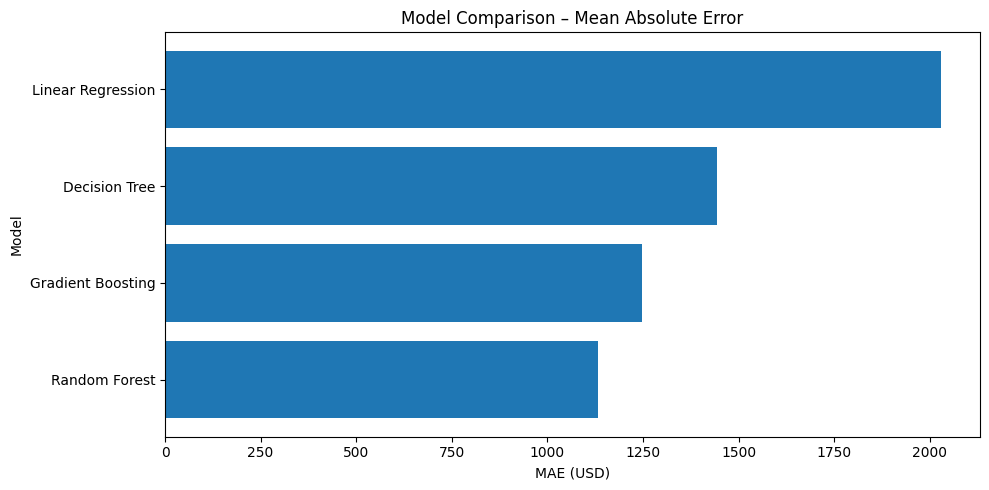

In [72]:
comparison_plot = comparison.sort_values("MAE")

plt.figure(figsize=(10, 5))
plt.barh(comparison_plot["Model"], comparison_plot["MAE"])
plt.title("Model Comparison – Mean Absolute Error")
plt.xlabel("MAE (USD)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


## 12. Final model

The model with the lowest MAE in the comparison is selected as the final model.

For this dataset and configuration, the **Random Forest Regressor** achieved the lowest MAE and was therefore selected.

The final model is saved as:

`models/car_price_model.joblib`


In [73]:
from source.model_training import train_final_model

train_final_model()


Final model training completed.
Model saved to: 'models/car_price_model.joblib'

Training rows: 44,428
Test rows: 11,107


## 13. Final model evaluation

The saved model is evaluated on the exact test set that was held out during training.

The most important number to interpret is MAE. For example, an MAE of about **$1,133** means that the model's predictions are, on average, approximately $1,133 away from the actual price in absolute terms.


In [74]:
from source.model_evaluation import evaluate_model

metrics, examples = evaluate_model()

display(metrics)
display(examples)


Final model evaluation:
MAE:  $1,132.99
MSE:  8,000,335.05
RMSE: $2,828.49
R²:   0.8799

Example predictions:
 Actual Price (USD)  Predicted Price (USD)  Absolute Error (USD)
               9700                8968.19                731.81
              22650               23336.33                686.33
               7700                8999.89               1299.89
               2999                3495.69                496.69
              18000               18035.71                 35.71
               8300                8620.63                320.63
               6200                6545.84                345.84
               9900               12992.11               3092.11
                972                1492.09                520.09
              10600               10999.52                399.52


,MAE,MSE,RMSE,R2
0,1132.992246,8.000335e+06,2828.486354,0.879932


,Actual Price (USD),Predicted Price (USD),Absolute Error (USD)
0,9700,8968.188790,731.811210
1,22650,23336.329200,686.329200
2,7700,8999.886358,1299.886358
3,2999,3495.693896,496.693896
4,18000,18035.710861,35.710861
...,...,...,...
11102,4900,4739.595831,160.404169
11103,11550,11460.348075,89.651925
11104,4600,5072.357466,472.357466
11105,800,1008.723316,208.723316


## 14. Actual vs. predicted prices

A strong regression model should place predictions close to the diagonal line where:

**Predicted Price = Actual Price**

Some larger deviations are expected because used-car prices are influenced by factors that are not always available in the dataset.


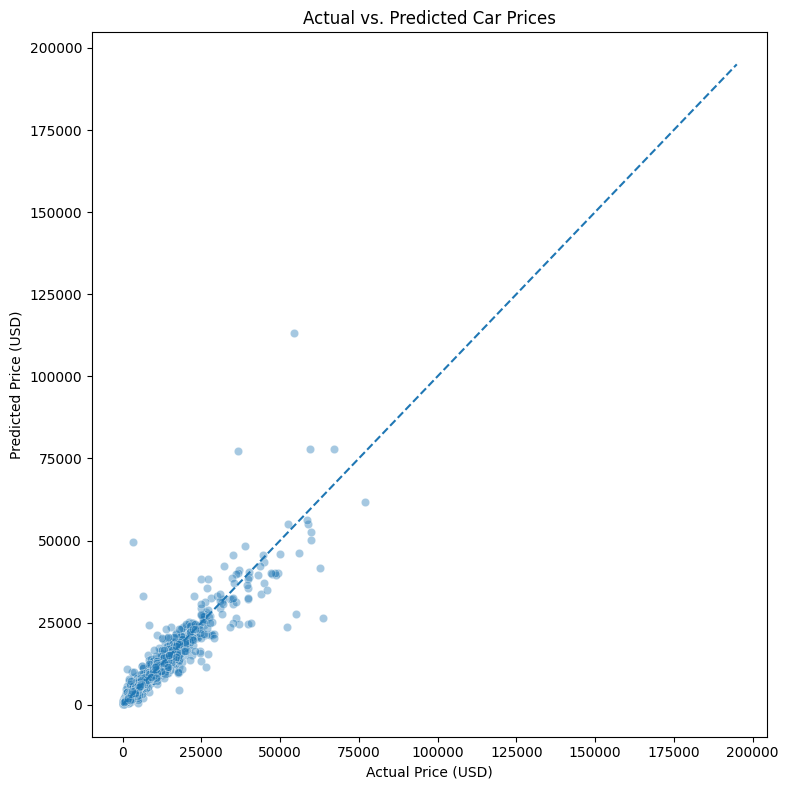

In [75]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=examples.sample(min(3000, len(examples)), random_state=42),
    x="Actual Price (USD)",
    y="Predicted Price (USD)",
    alpha=0.4
)

max_value = max(
    examples["Actual Price (USD)"].max(),
    examples["Predicted Price (USD)"].max()
)
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.title("Actual vs. Predicted Car Prices")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.tight_layout()
plt.show()


## 15. Example prediction

The model can also be used to estimate the price of a new car.

Example input:

- Volkswagen Passat
- 2016
- 216,000 km
- diesel
- 1,600 cm³
- white
- automatic transmission
- front-wheel drive
- segment C

The prediction is an estimate of market value, not a guaranteed selling price.


In [76]:

from source.predict import predict_price
from source.feature_engineering import add_features


example_car = {
    "make": "volkswagen",
    "model": "passat",
    "year": 2016,
    "condition": "with mileage",
    "mileage(kilometers)": 216000,
    "fuel_type": "diesel",
    "volume(cm3)": 1600,
    "color": "white",
    "transmission": "automatic",
    "drive_unit": "front-wheel drive",
    "segment": "C",
}

predicted_price = predict_price(example_car)
print("=" * 60)
print(f"Predicted market price: ${predicted_price:,.0f}")
print("=" * 60)

Predicted market price: $13,781


## 16. Conclusion

The project demonstrates a complete regression workflow for used-car price prediction.

### Main conclusions

- The raw dataset required basic data cleaning because it contained missing values and implausible extreme observations.
- Feature engineering added interpretable information such as vehicle age, mileage per year, engine volume in liters, and a combined brand/model feature.
- Numerical and categorical variables were handled with dedicated preprocessing pipelines.
- Four regression approaches were compared using the same train/test split.
- Random Forest achieved the lowest MAE in the final comparison and was selected as the final model.
- The final model achieved approximately **$1,132.99 MAE**, **$2,828.49 RMSE**, and **0.8799 R²** on the held-out test set.
- The model should be viewed as a market-price estimation tool rather than an exact valuation system.

### Possible future improvements

- Hyperparameter tuning with cross-validation.
- Target transformation such as `log1p(priceUSD)`.
- More detailed outlier analysis.
- Additional vehicle-specific features.
- External market information such as location, equipment level, service history, and seller type.
